In [69]:
import numpy as np, pandas as pd
import json
from pathlib import Path
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

RANDOM_STATE = 42
TARGET_COL = "Class"
TEST_SIZE = 0.2

In [90]:
PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

# Ensure the directory exists
DATA_RAW.mkdir(parents=True, exist_ok=True)
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Check if the file exists before reading
csv_file = DATA_RAW / "creditcard.csv"
if csv_file.exists():
    df = pd.read_csv(csv_file, low_memory=False)  # Suppress DtypeWarning
    df.head(10)
else:
    print(f"File not found: {csv_file}")

with open(MODELS_DIR / "hgb_best_params.json") as f:
    best_params = json.load(f)
print(best_params)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/uvlazhnitel/Documents/coding/DataScience/heart-disease-project/models/hgb_best_params.json'

In [71]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [72]:
train_idx = pd.read_csv(SPLITS_DIR / "X_train.csv", header=None).squeeze()

X_train = X.loc[train_idx].copy()
y_train = y.loc[train_idx].copy()

In [73]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

v_columns = [f"V{i}" for i in range(1, 29)]
amount_col = ["Amount"]
time_col = ["Time"]

SECONDS_IN_DAY = 86400

def time_cyc_features(X):
    t = (X % SECONDS_IN_DAY) / SECONDS_IN_DAY
    return np.hstack([np.sin(2 * np.pi * t), np.cos(2 * np.pi * t)])

def coerce_numeric_df(X):
    X = X.copy()
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X

to_numeric = FunctionTransformer(coerce_numeric_df, validate=False)

amount_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=True)),
    ("scaler", StandardScaler()),
])

v_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

time_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("cyc", FunctionTransformer(time_cyc_features, validate=True)),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("amount", amount_transformer, amount_col),
        ("time", time_transformer, time_col),
        ("v", v_transformer, v_columns),
    ],
    remainder="drop"
)

USE_SAMPLE_WEIGHT = True  # set True if you want it
W_POS = 200               # try 50, 100, 200

# Define the pipeline
model = Pipeline(steps=[
    ("to_numeric", to_numeric),
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_iter=288,
        learning_rate=0.19063571821788408,
        max_depth=10,
        max_bins=206,
        min_samples_leaf=11,
        max_leaf_nodes=35,
        l2_regularization=0.3745401188473625,
    ))
])

In [74]:

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

calibrated_model = CalibratedClassifierCV(
    estimator=model,
    method="isotonic",
    cv=cv
)

USE_SAMPLE_WEIGHT = True

if USE_SAMPLE_WEIGHT:
    sample_weight = np.where(y_train == 1, W_POS, 1)
    calibrated_model.fit(X_train, y_train, classifier__sample_weight=sample_weight)
else:
    calibrated_model.fit(X_train, y_train)

In [75]:
oof_proba_cal = calibrated_model.predict_proba(X_train)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_proba_cal)
thr_ext = np.r_[0.0, thresholds]
print(len(precision), len(recall), len(thr_ext))

3558 3558 3558


In [85]:
import sys
from pathlib import Path

# Add the parent directory of 'src' to sys.path
sys.path.append(str(PROJECT_ROOT))

from src.choose_thresholds import choose_threshold_max_recall_at_fpr

chosen_thr, strategy, metrics = choose_threshold_max_recall_at_fpr(
    y_true=y_train,
    proba=oof_proba_cal,
    max_fpr=0.001
)
print(f"Chosen threshold: {chosen_thr}, strategy: {strategy}")
print("Metrics at chosen threshold:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {round(metric_value, 4)}")

Chosen threshold: 0.4502900283651993, strategy: Max recall with FPR≤0.0010
Metrics at chosen threshold:
threshold: 0.4503
fpr: 0.0009
recall: 0.8452
precision: 0.6077
f1: 0.707


In [77]:
cm = confusion_matrix(y_train, (oof_proba_cal >= chosen_thr).astype(int))
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[227390     61]
 [     0    394]]


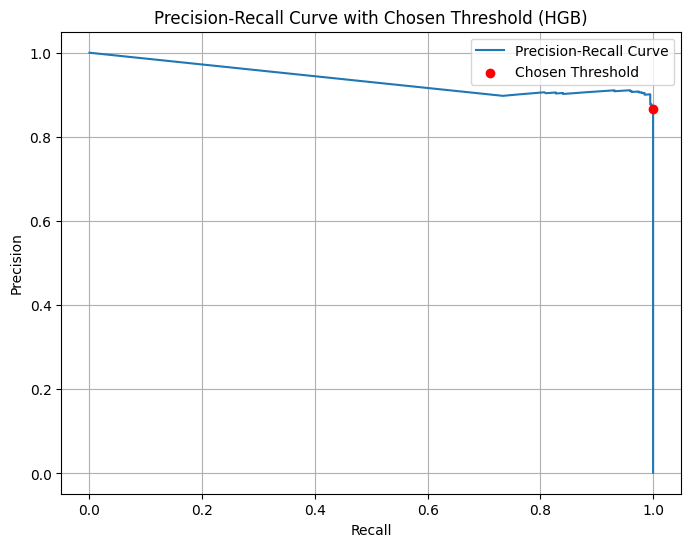

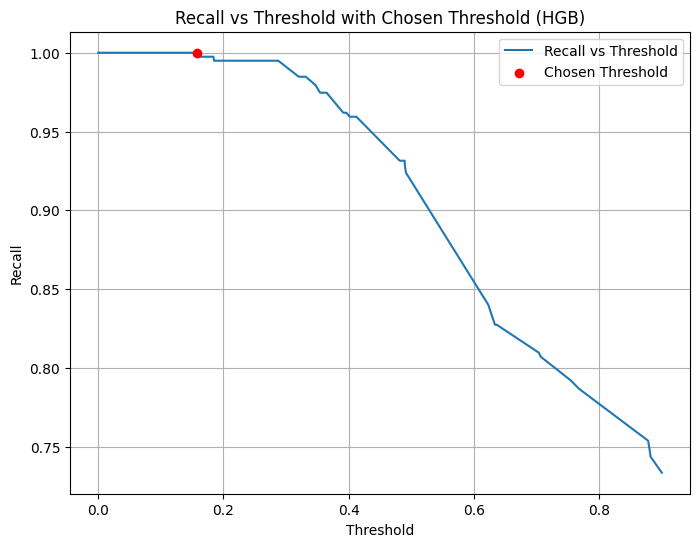

In [78]:
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# --- Precision-Recall curve + chosen operating point ---
prec_pr, rec_pr, thr_pr = precision_recall_curve(y_train, oof_proba_cal)

plt.figure(figsize=(8, 6))
plt.plot(rec_pr, prec_pr, label="Precision-Recall Curve")
plt.scatter(
    metrics["recall"],
    metrics["precision"],
    color="red",
    label="Chosen Threshold",
    zorder=5
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Chosen Threshold (HGB)")
plt.legend()
plt.grid()
plt.savefig(REPORTS_DIR / "pr_curve_chosen_threshold_hgb.png")
plt.show()

# --- Recall vs Threshold (use ROC curve thresholds; aligns naturally with FPR constraints) ---
fpr_roc, tpr_roc, thr_roc = roc_curve(y_train, oof_proba_cal)  # tpr_roc == recall

plt.figure(figsize=(8, 6))
plt.plot(thr_roc, tpr_roc, label="Recall vs Threshold")
plt.scatter(
    chosen_thr,
    metrics["recall"],
    color="red",
    label="Chosen Threshold",
    zorder=5
)
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Threshold with Chosen Threshold (HGB)")
plt.legend()
plt.grid()
plt.savefig(REPORTS_DIR / "recall_vs_threshold_chosen_threshold_hgb.png")
plt.show()


In [79]:
import numpy as np
from scipy.stats import uniform, randint

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve
from sklearn.metrics import make_scorer
from sklearn.model_selection import StratifiedKFold

# --- 1) Param search space (HGB) ---
param_distributions = {
    "classifier__learning_rate": uniform(0.01, 0.19),
    "classifier__max_leaf_nodes": randint(15, 50),
    "classifier__min_samples_leaf": randint(5, 30),
    "classifier__max_iter": randint(100, 600),
}

# --- 2) Custom scorer: maximize recall (TPR) subject to FPR <= max_fpr ---
def recall_at_max_fpr(y_true, y_score, max_fpr=0.001, **kwargs):
    """
    y_score is expected to be probability of positive class (fraud).
    **kwargs is required because newer sklearn may pass extra kwargs (e.g., needs_proba).
    """
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ok = np.where(fpr <= max_fpr)[0]
    return float(np.max(tpr[ok])) if ok.size else 0.0

recall_fpr_0p1_scorer = make_scorer(
    recall_at_max_fpr,
    needs_proba=True,   # tells sklearn to pass predict_proba output
    max_fpr=0.001       # passed to recall_at_max_fpr as kwarg
)

# --- 3) Multi-metric scoring; refit by your KPI ---
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall_fpr_0p1": recall_fpr_0p1_scorer,
}

# If you haven't defined skf yet, define it like this:
# (shuffle is important for randomized search reproducibility)
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=40,
    scoring=scoring,
    refit="recall_fpr_0p1",
    n_jobs=-1,
    cv=cv,
    random_state=RANDOM_STATE,
    verbose=2,
    error_score="raise",  # fail fast if something else breaks
)

# --- 4) class imbalance handling for HGB via sample_weight ---
# If you want "balanced" behavior for HistGradientBoostingClassifier, use sample weights:
USE_SAMPLE_WEIGHT = True  # set True if you want it
W_POS = 200              # try 50, 100, 200

if USE_SAMPLE_WEIGHT:
    sample_weight = np.where(y_train == 1, W_POS, 1.0)
    random_search.fit(X_train, y_train, classifier__sample_weight=sample_weight)
else:
    random_search.fit(X_train, y_train)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END classifier__learning_rate=0.08116262258099886, classifier__max_iter=448, classifier__max_leaf_nodes=29, classifier__min_samples_leaf=15; total time=   3.6s
[CV] END classifier__learning_rate=0.15814129005182617, classifier__max_iter=120, classifier__max_leaf_nodes=33, classifier__min_samples_leaf=27; total time=   3.6s
[CV] END classifier__learning_rate=0.15814129005182617, classifier__max_iter=120, classifier__max_leaf_nodes=33, classifier__min_samples_leaf=27; total time=   3.9s
[CV] END classifier__learning_rate=0.15814129005182617, classifier__max_iter=120, classifier__max_leaf_nodes=33, classifier__min_samples_leaf=27; total time=   3.9s
[CV] END classifier__learning_rate=0.15814129005182617, classifier__max_iter=120, classifier__max_leaf_nodes=33, classifier__min_samples_leaf=27; total time=   4.1s
[CV] END classifier__learning_rate=0.15814129005182617, classifier__max_iter=120, classifier__max_leaf_nodes=33, 

In [82]:
import json
import joblib
from sklearn.model_selection import cross_val_predict
# Set the best parameters for the model
best_model = random_search.best_estimator_

oof_proba_cal = cross_val_predict(
    best_model, 
    X_train, 
    y_train, 
    cv=cv, 
    method="predict_proba",
    params={"classifier__sample_weight": sample_weight})[:, 1]

chosen_thr, strategy, metrics = choose_threshold_max_recall_at_fpr(
    y_true=y_train,
    proba=oof_proba_cal,
    max_fpr=0.001
)

print(f"Chosen threshold after hyperparameter tuning: {chosen_thr}, strategy: {strategy}")

print("Metrics at chosen threshold after hyperparameter tuning:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {round(metric_value, 4)}")

best_params = random_search.best_params_

print("Best Parameters:", best_params)

joblib.dump(best_model, REPORTS_DIR / "final_model.pkl")
joblib.dump(chosen_thr, REPORTS_DIR / "best_threshold.pkl")


Chosen threshold after hyperparameter tuning: 0.4502900283651993, strategy: Max recall with FPR≤0.0010
Metrics at chosen threshold after hyperparameter tuning:
threshold: 0.4503
fpr: 0.0009
recall: 0.8452
precision: 0.6077
f1: 0.707
Best Parameters: {'classifier__learning_rate': np.float64(0.18850479889719593), 'classifier__max_iter': 545, 'classifier__max_leaf_nodes': 28, 'classifier__min_samples_leaf': 20}


['/Users/uvlazhnitel/Documents/coding/DataScience/heart-disease-project/reports/best_threshold.pkl']

In [83]:
cv_results_df = pd.DataFrame(random_search.cv_results_)

cv_results_sorted = cv_results_df.sort_values(
    by="mean_test_recall_fpr_0p1",
    ascending=False
)

cv_results_sorted.to_csv(REPORTS_DIR / "random_search_cv_results.csv", index=False)

top10 = cv_results_sorted.head(10)

# 4) Display only the most relevant columns
cols_to_show = [
    "mean_test_roc_auc",
    "mean_test_pr_auc",
    "mean_test_recall_fpr_0p1",
    "param_classifier__learning_rate",
    "param_classifier__max_leaf_nodes",
    "param_classifier__min_samples_leaf",
    "param_classifier__max_iter",
    "mean_test_recall_fpr_0p1"
]
top10[cols_to_show]

cv_results_df.to_csv(REPORTS_DIR / "random_search_cv_results.csv", index=False)
